### Imports

In [30]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


### Configuration

In [31]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "../data/processed/clahe"

MODEL_DIR = "../models/resnet50"
os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 5e-5
NUM_CLASSES = 4

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

Device: cuda


### Transformation et augmentation de la donnée

In [32]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.05,0.05),
        scale=(0.95,1.05)
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.RandomPerspective(
        distortion_scale=0.1,
        p=0.3
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.3,
        scale=(0.02,0.08)
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Datasets et Dataloaders

In [33]:
# Lecture de la liste utilisée comme référence
df = pd.read_csv("../data/processed/data_list.csv")

full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=None
)

class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes :", class_names)
print("Nombre total d'images :", len(full_dataset))

# Mapping ImageFolder : filename -> index
path_to_idx = {}
for idx, (path, label) in enumerate(full_dataset.samples):
    filename = os.path.basename(path)
    class_name = os.path.basename(os.path.dirname(path))
    key = (filename, class_name)
    path_to_idx[key] = idx

# Même split que pour le ML : 80% train_val / 20% test
df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=df["class"]
)

# Puis split train / val dans les 80% restants
# Ici : 60 / 20 / 20 global
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_ratio_adjusted,
    random_state=SEED,
    stratify=df_train_val["class"]
)

# Conversion des lignes CSV en indices ImageFolder
def df_to_indices(df_split):
    indices = []
    for _, row in df_split.iterrows():
        key = (row["image_name"], row["class"])
        indices.append(path_to_idx[key])
    return indices

train_idx = df_to_indices(df_train)
val_idx = df_to_indices(df_val)
test_idx = df_to_indices(df_test)

# Datasets avec transforms
train_dataset_base = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transforms
)

val_dataset_base = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transforms
)

test_dataset_base = datasets.ImageFolder(
    root=DATA_DIR,
    transform=eval_transforms
)

train_dataset = Subset(train_dataset_base, train_idx)
val_dataset = Subset(val_dataset_base, val_idx)
test_dataset = Subset(test_dataset_base, test_idx)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Nombre total d'images : 21165
Train : 12699
Val   : 4233
Test  : 4233


### Modèle

In [34]:
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

# Remplacement de la dernière couche
in_features = model.fc.in_features

model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Loss, Optimizer, Scheduler

In [35]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-3,
    min_lr=1e-7
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

### Entrainement

In [36]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)
    epoch_f1 = f1_score(y_true, y_pred, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

In [37]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true, y_pred)
    epoch_f1 = f1_score(y_true, y_pred, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, y_true, y_pred

In [38]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = 0.0

early_stopping_patience = 5
epochs_without_improvement = 0

t0 = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS} - lr {optimizer.param_groups[0]["lr"]:.2e}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Train loss: {train_loss:.4f} | acc: {train_acc:.4f} | f1_macro: {train_f1:.4f}")
    print(f"Val   loss: {val_loss:.4f} | acc: {val_acc:.4f} | f1_macro: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "resnet50_best.pth")
        )

        epochs_without_improvement = 0

        print("Best model saved.")

    else:
        epochs_without_improvement += 1

        print(
            f"No improvement "
            f"({epochs_without_improvement}/{early_stopping_patience})"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print("\nEarly stopping triggered.")
            break
        
    print("-" * 40)

print(f"\nTraining complete in {(time.time() - t0) / 60:.1f} min")
print(f"Best validation F1 macro: {best_val_f1:.4f}")

df_history = pd.DataFrame(history)

df_history.to_csv(
    os.path.join(MODEL_DIR, "resnet50_history.csv"),
    index=False
)

model.load_state_dict(best_model_wts)


Epoch 1/50 - lr 5.00e-05


Train loss: 0.5472 | acc: 0.7943 | f1_macro: 0.7520
Val   loss: 0.3359 | acc: 0.8816 | f1_macro: 0.8765
Best model saved.
----------------------------------------

Epoch 2/50 - lr 5.00e-05


Train loss: 0.3521 | acc: 0.8724 | f1_macro: 0.8587
Val   loss: 0.2960 | acc: 0.8883 | f1_macro: 0.8829
Best model saved.
----------------------------------------

Epoch 3/50 - lr 5.00e-05


Train loss: 0.2977 | acc: 0.8920 | f1_macro: 0.8834
Val   loss: 0.3218 | acc: 0.8885 | f1_macro: 0.8670
No improvement (1/5)
----------------------------------------

Epoch 4/50 - lr 5.00e-05


Train loss: 0.2663 | acc: 0.9061 | f1_macro: 0.9001
Val   loss: 0.2405 | acc: 0.9138 | f1_macro: 0.9142
Best model saved.
----------------------------------------

Epoch 5/50 - lr 5.00e-05


...

Train loss: 0.0381 | acc: 0.9874 | f1_macro: 0.9870
Val   loss: 0.2274 | acc: 0.9388 | f1_macro: 0.9456
No improvement (2/5)
----------------------------------------

Epoch 21/50 - lr 1.25e-05


Train loss: 0.0320 | acc: 0.9889 | f1_macro: 0.9887
Val   loss: 0.2424 | acc: 0.9350 | f1_macro: 0.9406
No improvement (3/5)
----------------------------------------

Epoch 22/50 - lr 6.25e-06


Train loss: 0.0276 | acc: 0.9909 | f1_macro: 0.9909
Val   loss: 0.2372 | acc: 0.9386 | f1_macro: 0.9440
No improvement (4/5)
----------------------------------------

Epoch 23/50 - lr 6.25e-06


Train loss: 0.0260 | acc: 0.9912 | f1_macro: 0.9912
Val   loss: 0.2366 | acc: 0.9374 | f1_macro: 0.9430
No improvement (5/5)

Early stopping triggered.

Training complete in 59.2 min
Best validation F1 macro: 0.9461


<All keys matched successfully>

### Résultats

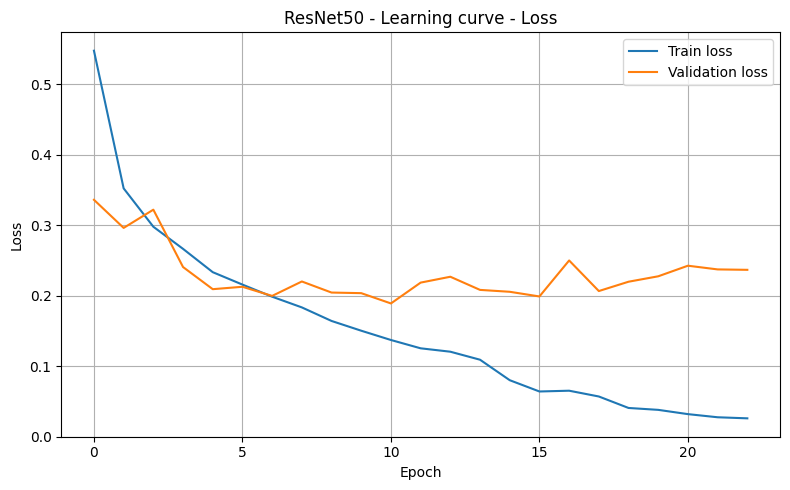

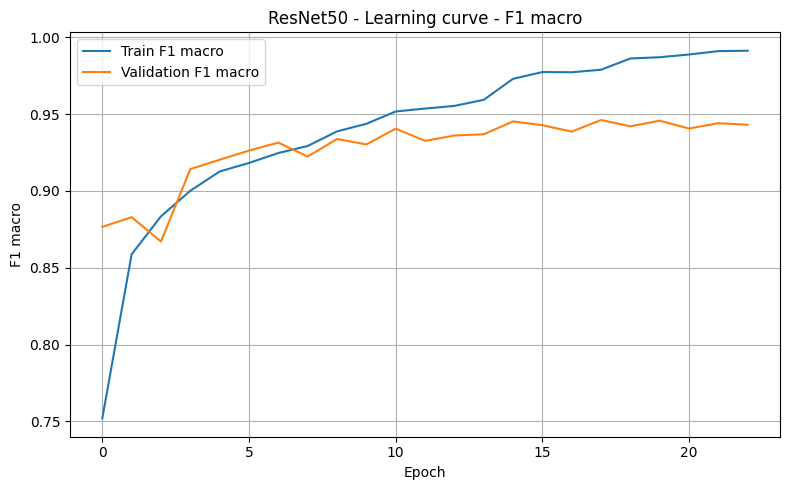

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("ResNet50 - Learning curve - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_f1"], label="Train F1 macro")
plt.plot(history["val_f1"], label="Validation F1 macro")
plt.title("ResNet50 - Learning curve - F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(8, 5))
# plt.plot(history["train_acc"], label="Train accuracy")
# plt.plot(history["val_acc"], label="Validation accuracy")
# plt.title("ResNet50 - Learning curve - Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Test loss: 0.2494
Test accuracy: 0.9331
Test F1 macro: 0.9377


Rapport de classification pour le modèle ResNet50:

                 precision    recall  f1-score   support

          COVID       0.96      0.91      0.93       723
   Lung_Opacity       0.93      0.90      0.91      1203
         Normal       0.92      0.96      0.94      2038
Viral Pneumonia       0.98      0.95      0.96       269

       accuracy                           0.93      4233
      macro avg       0.95      0.93      0.94      4233
   weighted avg       0.93      0.93      0.93      4233



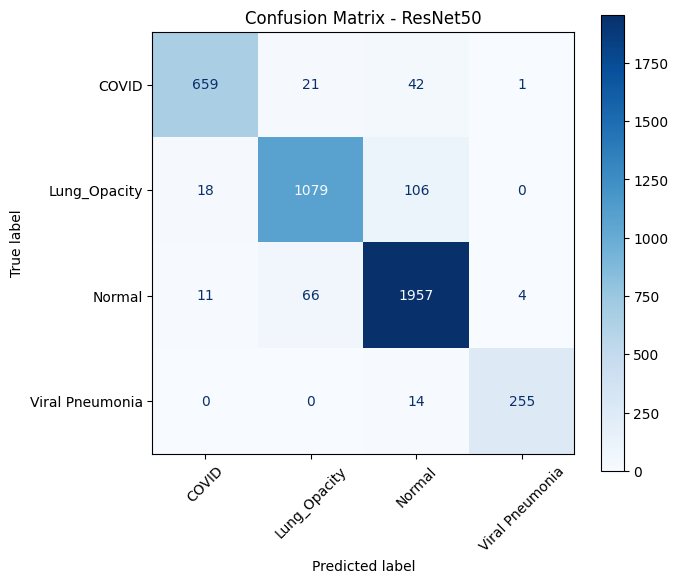

In [40]:
model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR, "resnet50_best.pth"),
        map_location=DEVICE
    )
)

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1 macro: {test_f1:.4f}")
print()
print("\nRapport de classification pour le modèle ResNet50:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()
plt.show()

In [41]:
# =============================================================================
# Prédictions
# =============================================================================
results = []
model.eval()

with torch.no_grad():
    for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
        image_name = row["image_name"]
        true_class = row["class"]
        
        image_path = os.path.join(DATA_DIR, true_class, image_name)
        image = Image.open(image_path).convert("L")

        input_tensor = (
            eval_transforms(image)
            .unsqueeze(0)
            .to(DEVICE)
        )

        outputs = model(input_tensor)

        probs = F.softmax(outputs, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()

        results.append({
            "image_name": image_name,
            "class": true_class,
            "prediction": class_names[pred_idx],
            "probability": probs[0, pred_idx].item()
        })

# =============================================================================
# DataFrame
# =============================================================================

df_predictions = pd.DataFrame(results)

# Colonne succès
df_predictions["success"] = (
    df_predictions["class"] == df_predictions["prediction"]
).astype(int)

# =============================================================================
# Tri des classes
# =============================================================================

class_order = [
    "Normal",
    "COVID",
    "Lung_Opacity",
    "Viral Pneumonia"
]

df_predictions["class"] = pd.Categorical(
    df_predictions["class"],
    categories=class_order,
    ordered=True
)

# Extraction du numéro de l'image
df_predictions["image_number"] = (
    df_predictions["image_name"]
    .str.extract(r"-(\d+)")
    .astype(int)
)

# Tri naturel
df_predictions = (
    df_predictions
    .sort_values(["class", "image_number"])
    .drop(columns="image_number")
    .reset_index(drop=True)
)

# =============================================================================
# Sauvegarde
# =============================================================================
output_csv = os.path.join(MODEL_DIR, "resnet50_predictions.csv")
df_predictions.to_csv(output_csv, index=False)

display(df_predictions)

print(f"\nCSV enregistré : {output_csv}")

100%|██████████| 4233/4233 [01:07<00:00, 62.59it/s]


,image_name,class,prediction,probability,success
0,Normal-8.png,Normal,Normal,0.998273,1
1,Normal-11.png,Normal,Normal,0.975368,1
2,Normal-12.png,Normal,Normal,0.984888,1
3,Normal-24.png,Normal,Normal,0.999960,1
4,Normal-26.png,Normal,Normal,0.991125,1
...,...,...,...,...,...
4228,Viral Pneumonia-1338.png,Viral Pneumonia,Normal,0.845658,0
4229,Viral Pneumonia-1339.png,Viral Pneumonia,Viral Pneumonia,0.999994,1
4230,Viral Pneumonia-1340.png,Viral Pneumonia,Viral Pneumonia,0.990633,1
4231,Viral Pneumonia-1344.png,Viral Pneumonia,Viral Pneumonia,0.999999,1



CSV enregistré : ../models/resnet50\resnet50_predictions.csv


In [42]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()